In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("data/Employee_Salary_Dataset.csv")
df.head()

,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                35 non-null     int64 
 1   Experience_Years  35 non-null     int64 
 2   Age               35 non-null     int64 
 3   Gender            35 non-null     object
 4   Salary            35 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB


,ID,Experience_Years,Age,Salary
count,35.000000,35.00000,35.000000,3.500000e+01
mean,18.000000,9.20000,35.485714,2.059147e+06
std,10.246951,7.55295,14.643552,3.170124e+06
min,1.000000,1.00000,17.000000,3.000000e+03
25%,9.500000,2.50000,22.500000,2.250000e+04
50%,18.000000,6.00000,29.000000,2.500000e+05
75%,26.500000,15.00000,53.500000,3.270000e+06
max,35.000000,27.00000,62.000000,1.000000e+07


In [5]:
df.isnull().sum()
df = df.dropna(subset=['Salary'])
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df = df.drop_duplicates()

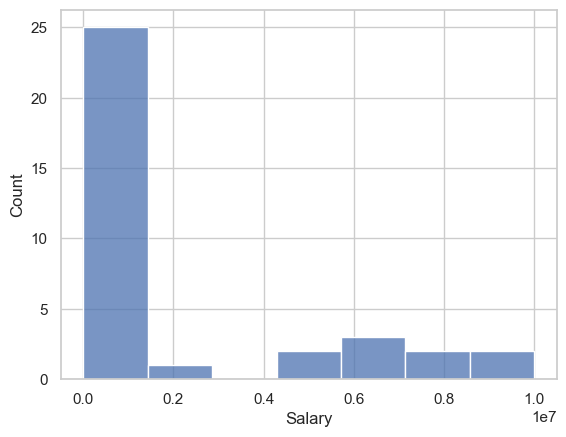

In [6]:
sns.histplot(df['Salary'])
plt.show()

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                35 non-null     int64 
 1   Experience_Years  35 non-null     int64 
 2   Age               35 non-null     int64 
 3   Gender            35 non-null     object
 4   Salary            35 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB


In [8]:
print("Average Salary:", df['Salary'].mean())
print("Median Salary:", df['Salary'].median())
print("Max Salary:", df['Salary'].max())
print("Min Salary:", df['Salary'].min())

Average Salary: 2059147.142857143
Median Salary: 250000.0
Max Salary: 10000000
Min Salary: 3000


In [9]:
exp_salary = df.groupby('Experience_Years')['Salary'].mean()
exp_salary

Experience_Years
1     1.725000e+04
2     1.252000e+04
3     9.500000e+04
4     9.272500e+04
5     3.547500e+06
6     1.400000e+06
10    3.503750e+05
11    2.201000e+05
14    6.000050e+06
15    4.005000e+06
16    7.600000e+06
19    5.033333e+06
20    1.540000e+06
25    5.001000e+06
27    1.000000e+07
Name: Salary, dtype: float64

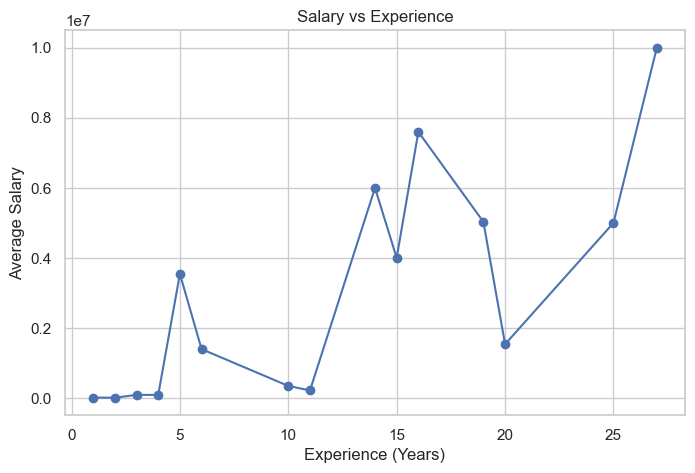

In [10]:
exp_salary.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Salary vs Experience")
plt.xlabel("Experience (Years)")
plt.ylabel("Average Salary")
plt.show()

In [11]:
age_salary = df.groupby('Age')['Salary'].mean()
age_salary

Age
17    1.000000e+04
18    3.000000e+03
21    1.722000e+04
22    2.250000e+04
23    6.213333e+04
26    1.375000e+05
27    8.700000e+04
28    2.500000e+05
29    4.122500e+06
34    5.050000e+05
36    1.957500e+05
39    6.000050e+06
40    2.201000e+05
49    7.600000e+06
53    9.300000e+06
54    3.636667e+06
55    1.540000e+06
62    7.500500e+06
Name: Salary, dtype: float64

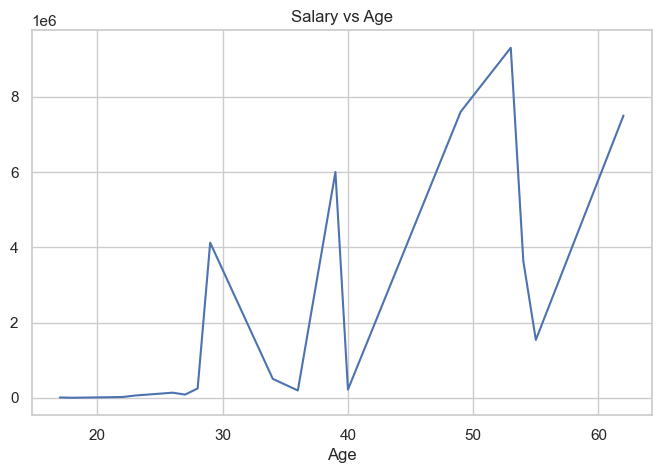

In [12]:
age_salary.plot(figsize=(8,5))
plt.title("Salary vs Age")
plt.show()

In [13]:
df.groupby('Gender')['Salary'].mean()

Gender
Female    2.054917e+06
Male      2.063626e+06
Name: Salary, dtype: float64

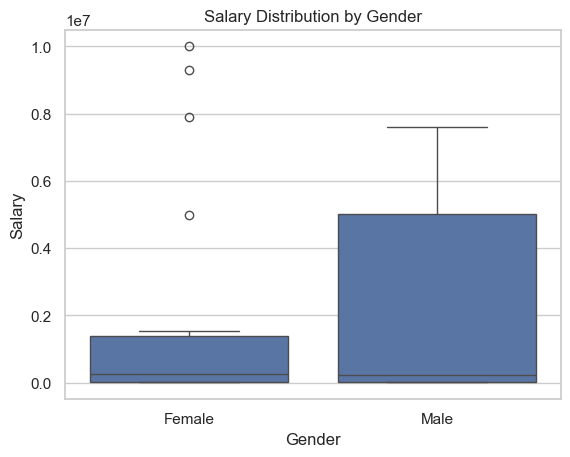

In [14]:
sns.boxplot(x='Gender', y='Salary', data=df)
plt.title("Salary Distribution by Gender")
plt.show()

In [17]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

<Axes: >

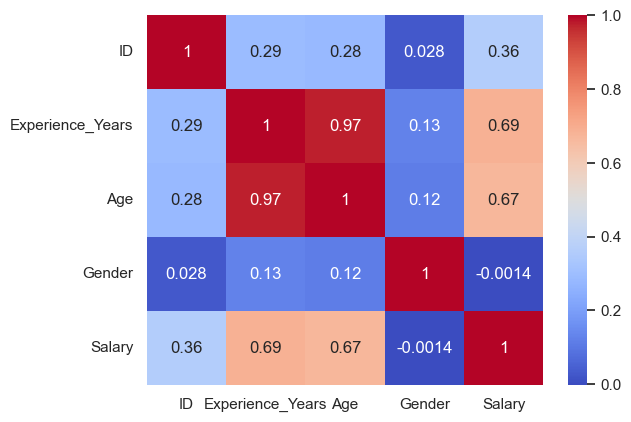

In [18]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [20]:
df.sort_values(by='Salary', ascending=False).head(5)

,ID,Experience_Years,Age,Gender,Salary
27,28,27,62,1,10000000
33,34,19,53,1,9300000
17,18,15,54,1,7900000
34,35,16,49,0,7600000
22,23,5,29,0,6845000


In [21]:
top5 = df.sort_values(by='Salary', ascending=False).head(5)
top5

,ID,Experience_Years,Age,Gender,Salary
27,28,27,62,1,10000000
33,34,19,53,1,9300000
17,18,15,54,1,7900000
34,35,16,49,0,7600000
22,23,5,29,0,6845000
